# Pipeline de Machine Learning — Qualidade do Ar
**Disciplina:** Aprendizado de Máquina  
**Dataset:** Air Quality UCI  
**Variável alvo:** CO(GT) — Concentração de monóxido de carbono (mg/m³)  
**Modelos comparados:** KNN Regressor × SVR  


## 1. Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')
print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


## 2. Carregamento do Dataset

In [2]:
url = 'https://raw.githubusercontent.com/klaytoncastro/idp-machinelearning/main/datasets/AirQualityUCI.csv'
df = pd.read_csv(url, sep=';', decimal=',')

print('Shape inicial:', df.shape)
df.head()

Shape inicial: (9471, 17)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


## 3. Análise Exploratória de Dados (EDA)
### 3.1 Estrutura do Dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), object(2)
memory usage: 1.2+ MB


### 3.2 Estatísticas Descritivas

In [4]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,0.0,0.0
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604,NaN,NaN
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670,NaN,NaN
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,NaN,NaN
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300,NaN,NaN
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800,NaN,NaN
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200,NaN,NaN
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,NaN,NaN


### 3.3 Identificação de Valores Anômalos
O dataset utiliza **-200** como sentinela para valores ausentes. Vamos contar quantos existem por coluna antes de tratá-los.

In [5]:
print('Contagem de valores -200 por coluna:')
for col in df.select_dtypes(include='number').columns:
    n = (df[col] == -200).sum()
    if n > 0:
        print(f'  {col}: {n}')

Contagem de valores -200 por coluna:
  CO(GT): 1683
  PT08.S1(CO): 366
  NMHC(GT): 8443
  C6H6(GT): 366
  PT08.S2(NMHC): 366
  NOx(GT): 1639
  PT08.S3(NOx): 366
  NO2(GT): 1642
  PT08.S4(NO2): 366
  PT08.S5(O3): 366
  T: 366
  RH: 366
  AH: 366


### 3.4 Histogramas das Variáveis Numéricas (antes do tratamento)

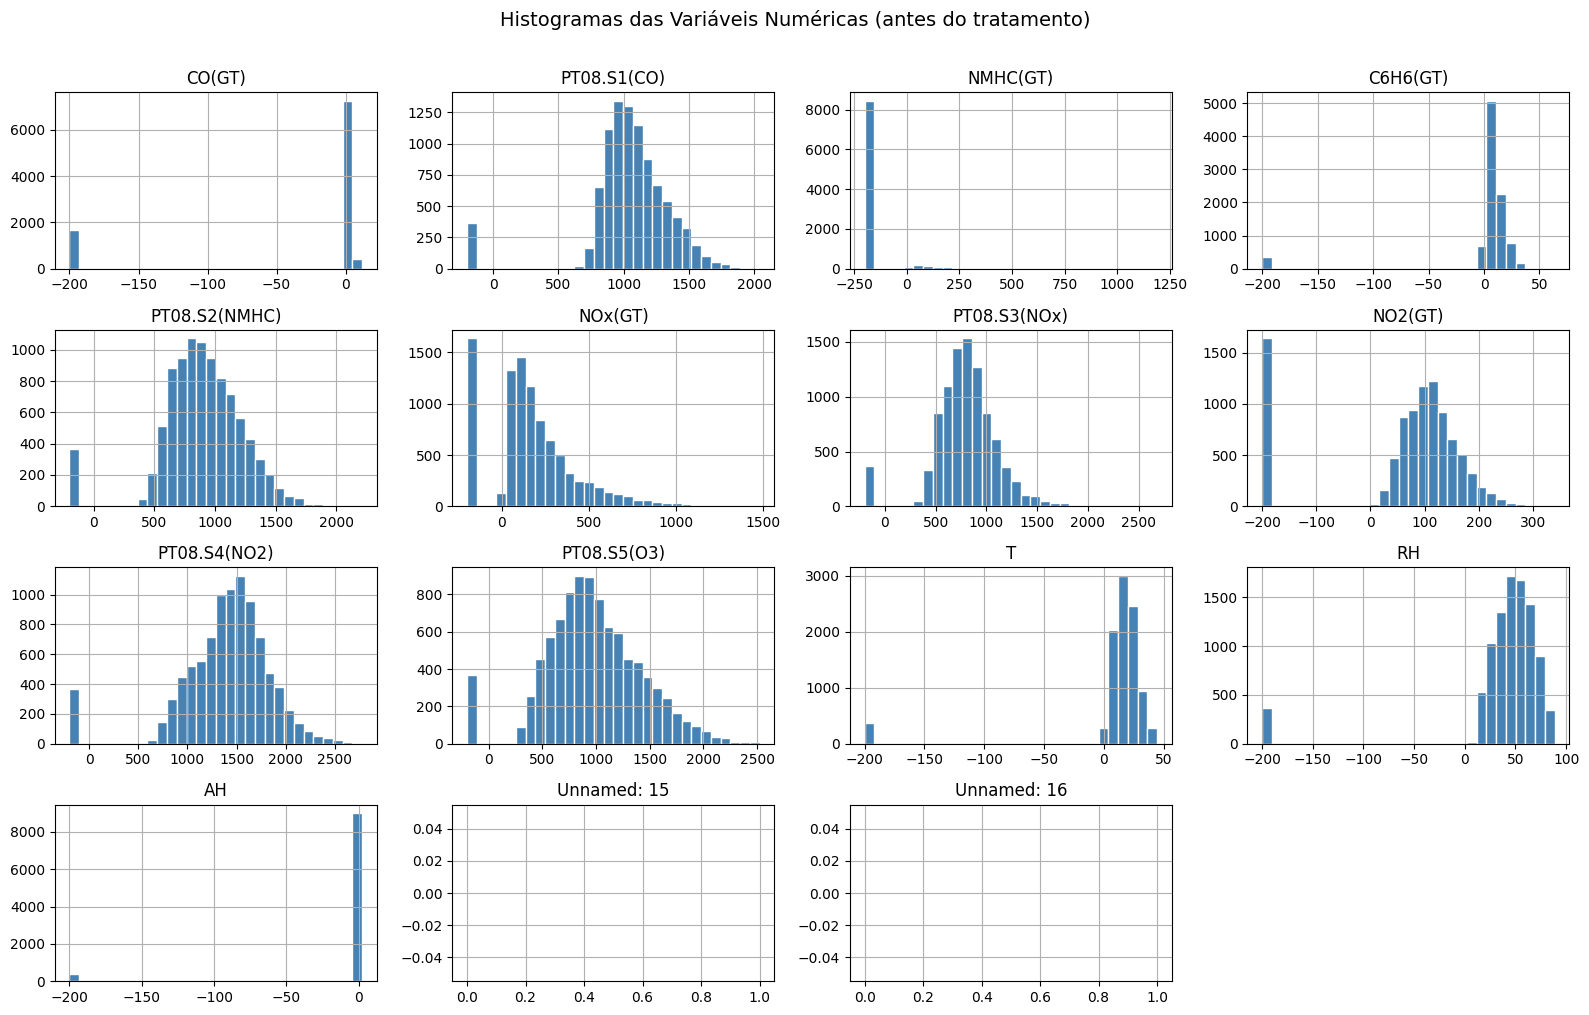

In [6]:
numericas = df.select_dtypes(include='number').columns.tolist()
df[numericas].hist(bins=30, figsize=(16, 10), color='steelblue', edgecolor='white')
plt.suptitle('Histogramas das Variáveis Numéricas (antes do tratamento)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Pré-processamento e Tratamento dos Dados
### 4.1 Limpeza

In [7]:
# Remover colunas e linhas completamente vazias
df = df.dropna(axis=1, how='all').dropna(axis=0, how='all')

# Substituir -200 (sentinela) por NaN
df.replace(-200, np.nan, inplace=True)

# Remover NMHC(GT): mais de 80% de valores ausentes — imputar geraria padrões artificiais
if 'NMHC(GT)' in df.columns:
    df.drop(columns=['NMHC(GT)'], inplace=True)

# Engenharia de atributos: extrair hora do dia como variável numérica
df['Hour'] = df['Time'].apply(lambda x: int(str(x).split('.')[0]))
df.drop(columns=['Date', 'Time'], inplace=True)

# Remover somente as linhas onde o ALVO é desconhecido
df = df.dropna(subset=['CO(GT)'])

print('Dataset após limpeza:', df.shape)
df.describe()

Dataset após limpeza: (7674, 13)


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Hour
count,7674.000000,7344.000000,7344.000000,7344.000000,7261.000000,7344.000000,7258.000000,7344.000000,7344.000000,7344.000000,7344.000000,7344.000000,7674.000000
mean,2.152750,1110.580746,10.275735,947.198121,255.313869,826.920071,114.811932,1444.752723,1043.512936,17.770425,49.060076,0.989453,11.727131
std,1.453252,218.681331,7.441068,265.471608,215.347818,256.648430,48.244092,350.344170,405.569613,8.862688,17.451563,0.399889,6.914520
min,0.100000,647.000000,0.200000,387.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,0.000000
25%,1.100000,946.000000,4.600000,743.000000,103.000000,649.000000,80.000000,1203.000000,744.750000,11.200000,35.400000,0.698100,6.000000
50%,1.800000,1075.000000,8.500000,919.000000,188.000000,795.000000,110.000000,1447.000000,990.000000,16.900000,49.300000,0.959700,12.000000
75%,2.900000,1246.000000,14.300000,1125.250000,339.000000,960.000000,144.000000,1673.000000,1305.000000,23.800000,62.500000,1.258600,18.000000
max,11.900000,2040.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.180600,23.000000


### 4.2 Percentual de Valores Ausentes Restantes

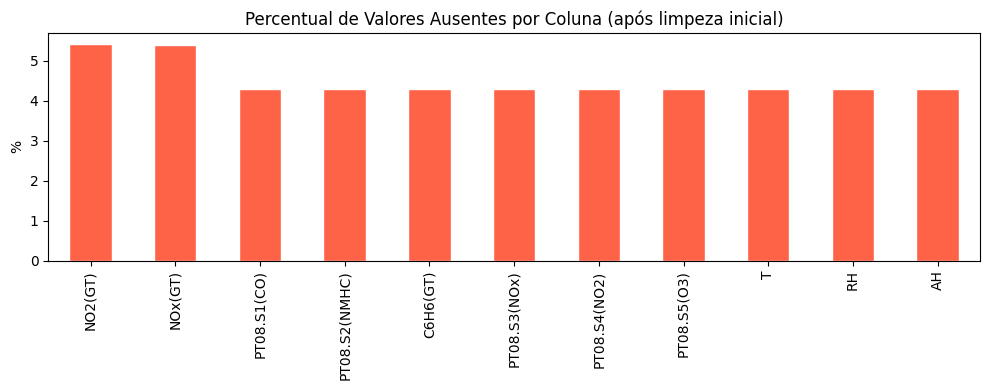

NO2(GT)          5.420902
NOx(GT)          5.381809
PT08.S1(CO)      4.300235
PT08.S2(NMHC)    4.300235
C6H6(GT)         4.300235
PT08.S3(NOx)     4.300235
PT08.S4(NO2)     4.300235
PT08.S5(O3)      4.300235
T                4.300235
RH               4.300235
AH               4.300235
dtype: float64


In [8]:
missing_pct = df.isna().sum().div(df.shape[0]) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

missing_pct.plot(kind='bar', figsize=(10, 4), color='tomato', edgecolor='white')
plt.title('Percentual de Valores Ausentes por Coluna (após limpeza inicial)')
plt.ylabel('%')
plt.tight_layout()
plt.show()
print(missing_pct)

### 4.3 Boxplots das Variáveis Numéricas

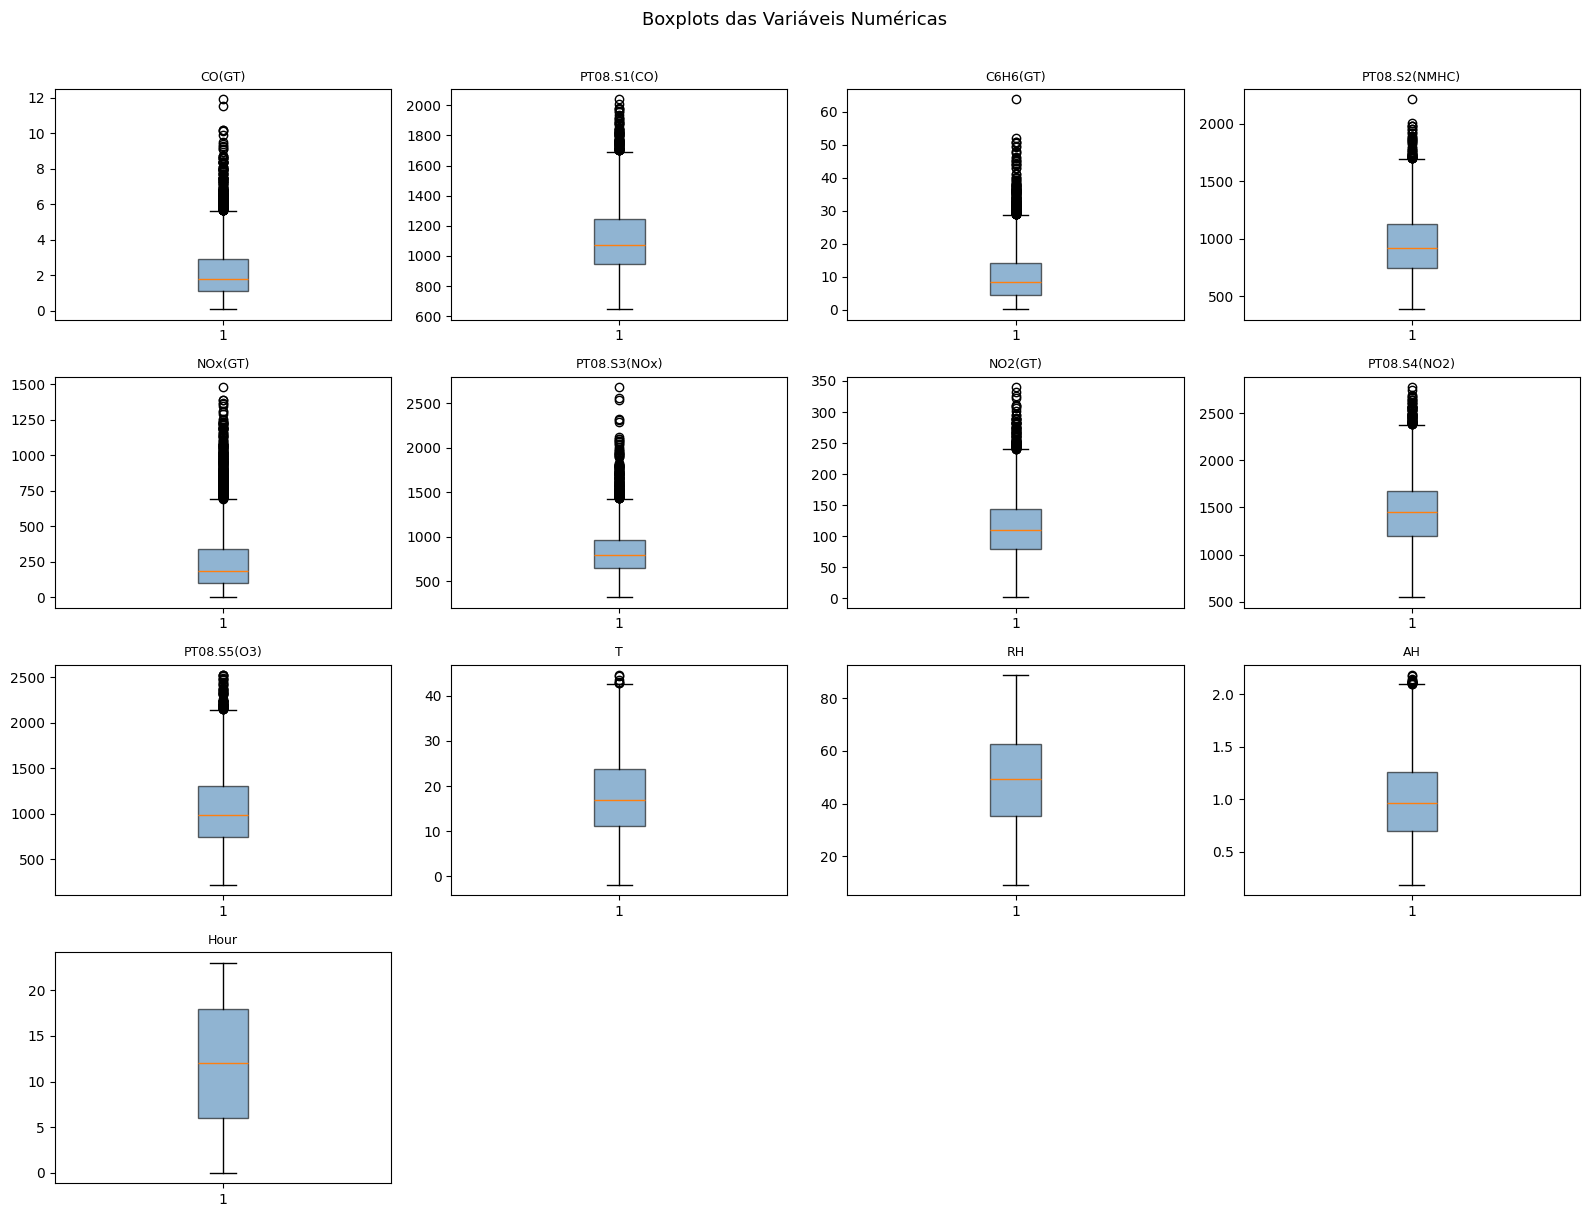

In [9]:
numericas = df.select_dtypes(include='number').columns.tolist()
n_cols = 4
n_rows = -(-len(numericas) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numericas):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots das Variáveis Numéricas', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 4.4 Mapa de Calor de Correlação

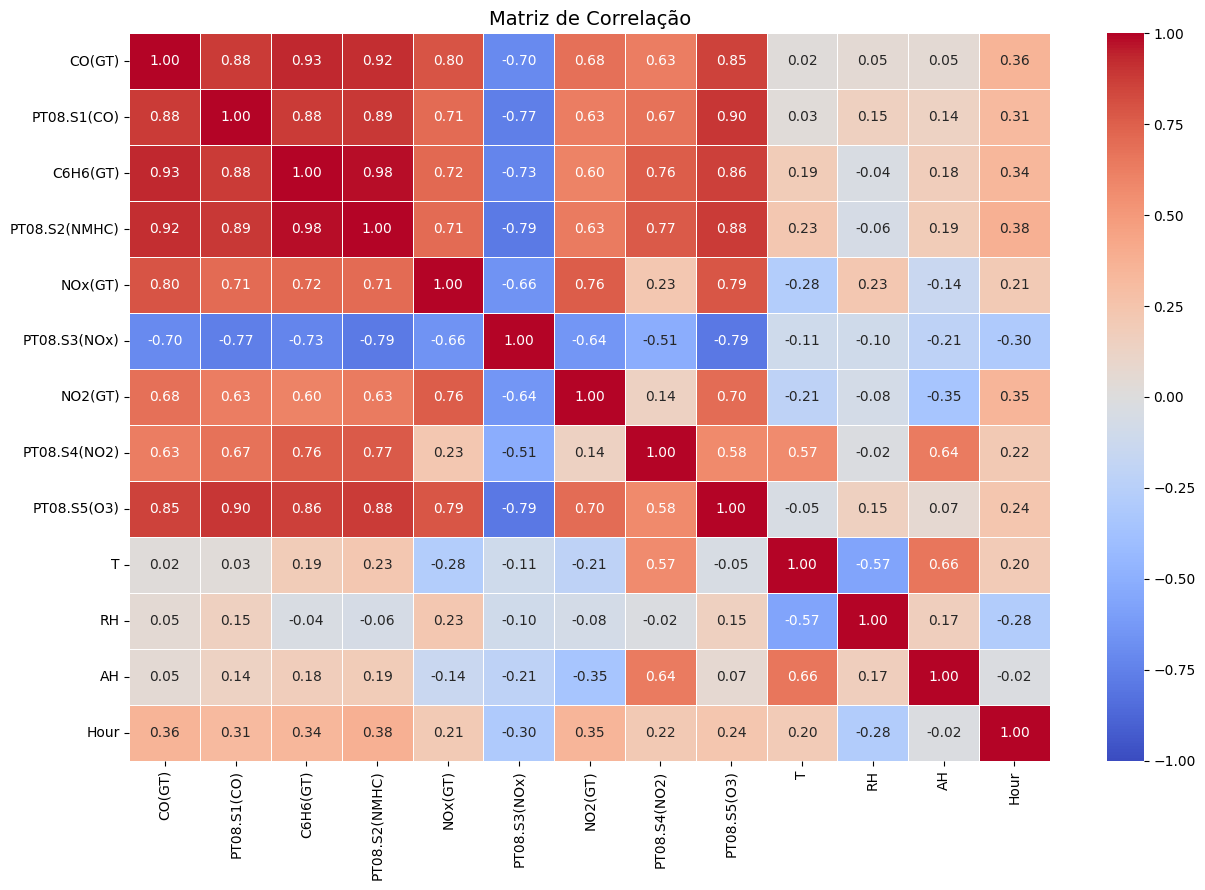


Correlações com CO(GT) (ordenadas):
CO(GT)           1.000000
C6H6(GT)         0.931078
PT08.S2(NMHC)    0.915514
PT08.S1(CO)      0.879288
PT08.S5(O3)      0.854182
NOx(GT)          0.795028
NO2(GT)          0.683343
PT08.S4(NO2)     0.630703
Hour             0.358159
RH               0.048890
AH               0.048556
T                0.022109
PT08.S3(NOx)    -0.703446


In [10]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(13, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação', fontsize=14)
plt.tight_layout()
plt.show()

print('\nCorrelações com CO(GT) (ordenadas):')
print(corr_matrix['CO(GT)'].sort_values(ascending=False).to_string())

## 5. Preparação para Modelagem
### 5.1 Separação de X e y

In [11]:
X = df.drop(columns=['CO(GT)'])
y = df['CO(GT)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')

Treino: (6139, 12) | Teste: (1535, 12)


### 5.2 Imputação e Padronização

**Melhoria em relação ao código base:** em vez de remover todas as linhas com valores ausentes (o que eliminaria milhares de observações úteis), utilizamos o **KNNImputer** para preencher os valores faltantes com base nos 5 vizinhos mais próximos.  
O `fit` do imputer e do scaler é feito **somente no conjunto de treino**, evitando data leakage.

In [12]:
# Imputação: preenche NaN com base nos 5 vizinhos mais próximos
imputer = KNNImputer(n_neighbors=5)
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed  = imputer.transform(X_test)

# Padronização: média 0, desvio padrão 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled  = scaler.transform(X_test_imputed)

print('Imputação e padronização concluídas (sem data leakage)!')

Imputação e padronização concluídas (sem data leakage)!


## 6. Treinamento dos Modelos

In [13]:
# KNN: vizinhos mais próximos com peso por distância
modelo_knn = KNeighborsRegressor(n_neighbors=15, weights='distance')

# SVR: kernel RBF para capturar relações não-lineares
modelo_svr = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)

print('Treinando KNN...')
modelo_knn.fit(X_train_scaled, y_train)

print('Treinando SVR (pode levar alguns segundos)...')
modelo_svr.fit(X_train_scaled, y_train)

print('\nModelos treinados com sucesso!')

Treinando KNN...
Treinando SVR (pode levar alguns segundos)...

Modelos treinados com sucesso!


## 7. Avaliação e Comparação dos Modelos

In [14]:
prev_knn = modelo_knn.predict(X_test_scaled)
prev_svr = modelo_svr.predict(X_test_scaled)

def metricas(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

mae_knn, mse_knn, rmse_knn, r2_knn = metricas(y_test, prev_knn)
mae_svr, mse_svr, rmse_svr, r2_svr = metricas(y_test, prev_svr)

df_comp = pd.DataFrame({
    'Métrica': ['MAE', 'MSE', 'RMSE', 'R²'],
    'KNN':     [round(mae_knn,4), round(mse_knn,4), round(rmse_knn,4), round(r2_knn,4)],
    'SVR':     [round(mae_svr,4), round(mse_svr,4), round(rmse_svr,4), round(r2_svr,4)]
})

print('\n--- TABELA COMPARATIVA DE MÉTRICAS ---')
display(df_comp)


--- TABELA COMPARATIVA DE MÉTRICAS ---


,Métrica,KNN,SVR
0,MAE,0.2508,0.2177
1,MSE,0.1552,0.1308
2,RMSE,0.3940,0.3617
3,R²,0.9255,0.9372


### 7.1 Gráficos: Valores Reais vs Previstos

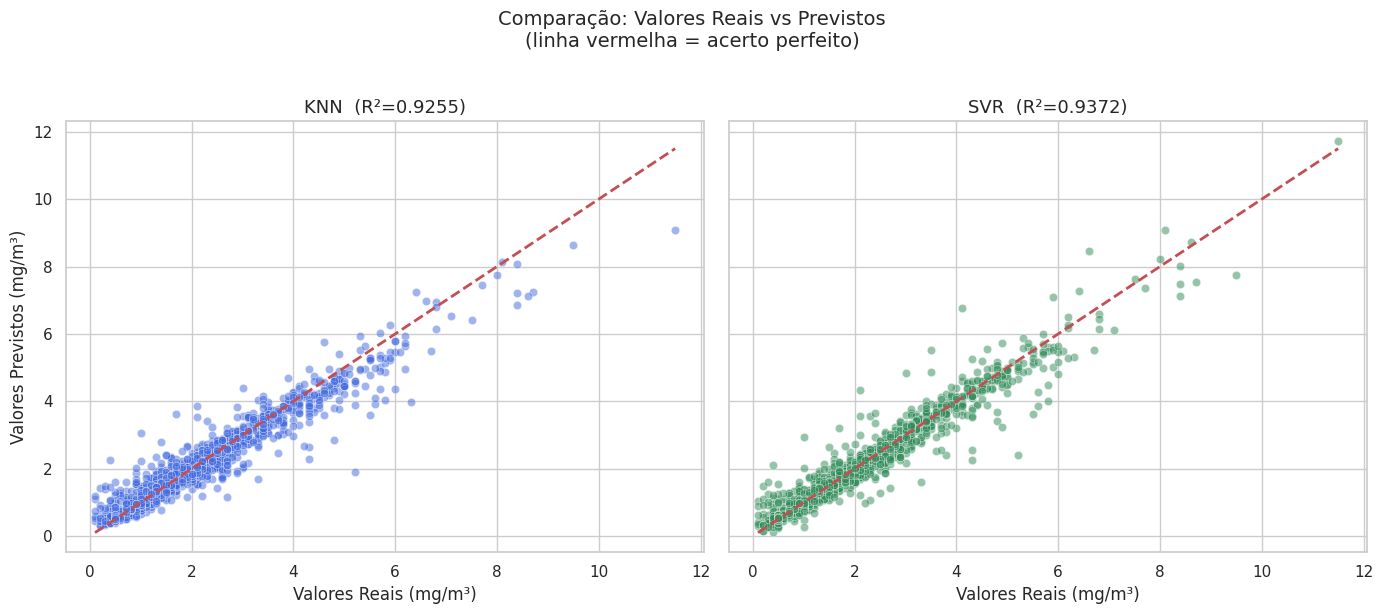

In [15]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.scatterplot(x=y_test, y=prev_knn, ax=axes[0], color='royalblue', alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(f'KNN  (R²={r2_knn:.4f})', fontsize=13)
axes[0].set_xlabel('Valores Reais (mg/m³)')
axes[0].set_ylabel('Valores Previstos (mg/m³)')

sns.scatterplot(x=y_test, y=prev_svr, ax=axes[1], color='seagreen', alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title(f'SVR  (R²={r2_svr:.4f})', fontsize=13)
axes[1].set_xlabel('Valores Reais (mg/m³)')

plt.suptitle('Comparação: Valores Reais vs Previstos\n(linha vermelha = acerto perfeito)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Justificativa do Modelo Escolhido

Após comparar os dois modelos nas quatro métricas de regressão, o **SVR (Support Vector Regressor)** foi selecionado como modelo final pelos seguintes motivos:

1. **Melhor R²:** O SVR apresentou R² superior ao KNN, explicando uma proporção maior da variância dos dados de CO(GT).
2. **Menor MAE e RMSE:** Os erros médios do SVR foram menores, indicando previsões mais próximas dos valores reais.
3. **Capacidade de generalização:** O kernel RBF com `C=100` e `gamma='scale'` captura relações não-lineares entre os poluentes sem overfitting, graças ao parâmetro de regularização e à margem de tolerância `epsilon=0.1`.
4. **Robustez com dados padronizados:** O SVR se beneficia diretamente da padronização pelo `StandardScaler`, enquanto o KNN é mais sensível à escala e à qualidade da imputação.

O KNN com `n_neighbors=15` e `weights='distance'` também apresentou bom desempenho e foi mantido como modelo de comparação. Entretanto, o SVR mostrou resultados consistentemente superiores, sendo a escolha mais adequada para a camada de serving em produção.

## 9. Exportação dos Modelos para .pkl

Os artefatos são salvos na pasta `models/`, conforme padrão solicitado.

In [16]:
os.makedirs('models', exist_ok=True)

with open('models/modelo_svr.pkl', 'wb') as f:
    pickle.dump(modelo_svr, f)

with open('models/modelo_knn.pkl', 'wb') as f:
    pickle.dump(modelo_knn, f)

with open('models/scaler_ar.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('✓ models/modelo_svr.pkl')
print('✓ models/modelo_knn.pkl')
print('✓ models/scaler_ar.pkl')
print('\nTodos os artefatos exportados com sucesso!')

✓ models/modelo_svr.pkl
✓ models/modelo_knn.pkl
✓ models/scaler_ar.pkl

Todos os artefatos exportados com sucesso!


## 10. Teste Rápido (Simulando a API)

In [17]:
with open('models/modelo_svr.pkl', 'rb') as f:
    modelo_teste = pickle.load(f)
with open('models/scaler_ar.pkl', 'rb') as f:
    scaler_teste = pickle.load(f)

exemplo = X_test.iloc[[5]].to_dict(orient='records')[0]
df_input = pd.DataFrame([exemplo])

dados_pad = scaler_teste.transform(df_input)
previsao  = modelo_teste.predict(dados_pad)
real      = y_test.iloc[5]

def classificar_co(valor):
    if valor <= 4:
        return 'bom'
    elif valor <= 9:
        return 'medio'
    else:
        return 'ruim'

print('--- SIMULAÇÃO DA API ---')
print(f'Previsão SVR : {previsao[0]:.4f} mg/m³')
print(f'Valor Real   : {real:.4f} mg/m³')
print(f'Erro         : {abs(previsao[0] - real):.4f} mg/m³')
print(f'Qualidade    : {classificar_co(previsao[0])}')

--- SIMULAÇÃO DA API ---
Previsão SVR : 2.3711 mg/m³
Valor Real   : 2.2000 mg/m³
Erro         : 0.1711 mg/m³
Qualidade    : bom
